<a href="https://colab.research.google.com/github/maxsantana-data2strategy/urbanmobility_economicproductivity/blob/main/notebook/S5_ladb_mobility_economy_project_student_draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction

The objective of this project is **to evaluate how urban mobility relates to economic productivity in major Latin American cities.**

To achieve this, real data from the TomTom Traffic Index and OECD Cities is cleaned, combined, and analyzed to identify which cities should receive investment in transportation infrastructure.

## 🧩 1: Load and quick view

Before cleaning or combining the data, **it is necessary to become familiar with the structure of both datasets.** At this stage, it is essential to verify that the files load correctly, review their columns and data types, and detect potential inconsistencies.

**🎯Objective:**
Import the necessary libraries, load the CSV files into DataFrames, and perform a preliminary review to understand their content.
### 1.1 Importing libraries
**Steps:**
- Import the `pandas`, `numpy`, `seaborn`, and `matplotlib.pyplot` libraries.
- Load files using `pd.read_csv()`:
  - `tomtom_traffic.csv`
  - `oecd_city_economy.csv`.
- Save the DataFrames `traffic` and `eco` variables.
- Show the first 5 rows in each DataFrame.


In [6]:
# loading libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1.2 Loading files and quick views

In [7]:
from google.colab import drive
drive.mount('/content/drive')

# Loading files
traffic = pd.read_csv('/content/drive/MyDrive/Python (datasets y notebooks)/datasets/Sprint 5/tomtom_traffic.csv')
eco = pd.read_csv('/content/drive/MyDrive/Python (datasets y notebooks)/datasets/Sprint 5/oecd_city_economy.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Disclosing the first five rows of the traffic dataframe
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [9]:
# Disclosing the first five rows of the eco dataframe
eco.head()


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



### 1.3 Key Observations & Action Plan:

1. **Potential Merge Keys:** The `traffic` and `eco` DataFrames can be joined using `country` and `city`. Additionally, the `year` column will need to be extracted from `update_time_utc` in `traffic` to match the `year` column in `eco`.
2. **Column Naming:** All column names should be standardized to `snake_case` format for consistency.
3. **`city_gdp_capita` formatting:** Values use European number formatting (and are stored as strings). Thousands separators (`.`) must be removed and decimal commas (`,`) replaced with dots (`.`) before converting to `float`.
4. **`unemployment_pct` formatting:** The `%` symbol must be removed and commas (`,`) replaced with dots (`.`) before converting to `float`.
5. **`population_m` Formatting & absolute population:** Replace decimal commas (,) with dots (.) before converting population_m to float. Then, create a new `population` column by multiplying population_m by 1,000,000 to represent the total population in absolute numbers.



---

## 🧩2: Data wrangling

Before combining the datasets, the structure is inspected in each dataframe, identifying data types, columns, and missing values. Columns that need cleaning are transformed and renamed in standard formats.

### 2.1 Exploring data structure and data types

**🎯Objetive:**
Identify columns with incorrect data types, distribution, and missing values, and note the columns that require conversion.

**Step by step:**

- .info() is used to inspect the structure of both DataFrames.
- The first 3 rows of each DF are disclosed
- A careful review is done to identify whether the details of each DF are fine or if they require corrections.

In [10]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

**Key Observations**

The data structure of the traffic df shows that:
- The "UpdateTimeUTC" and "UpdateTimeUTCWeekAgo" columns are text types, so they require proper conversion to a datetime data type.
- Before that, it is necessary to extract the year from these columns into a new 'Year' column.
- Identify the difference between UpdateTimeUTC and UpdateTimeUTCWeekAgo to determine which one should be used to build the 'Year' variable.
- No nulls are identified

In [11]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


**Key Observations**

The structure of the df "eco" indicates that:
- Columns `City GDP/capita`, `Unemployment %`, `Unemployment %`, `PM2.5 (μg/m³)` and `Population (M)`, `PM2.5 (μg/m³)` are wrongly stored as text variables. They need to be changed to float data types as they contain key numerical observations for our assessment

### 2.2 Rename columns

**🎯Objective:**
Standardize columns' names to prevent errors and facilitate the merging of databases in next steps.

**Instructions:**

- Change the names of columns to the standard `snake_case` convention.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verify that all changes have been applied correctly using `.columns`.


In [12]:
# Standardizing names of columns in the traffic dataset

traffic = traffic.rename(
    columns={
        "Country": "country",
        "City": "city",
        "UpdateTimeUTC": "update_time_utc",
        "JamsDelay": "jams_delay",
        "TrafficIndexLive": "traffic_index_live",
        "JamsLengthInKms": "jams_length_in_kms",
        "JamsCount": "jams_count",
        "TrafficIndexWeekAgo": "traffic_index_week_ago",
        "UpdateTimeUTCWeekAgo": "update_time_utc_week_ago",
        "TravelTimeLivePer10KmsMins": "travel_time_live_per_10kms_mins",
        "TravelTimeHistoricPer10KmsMins": "travel_time_historic_per_10kms_mins",
        "MinsDelay": "mins_delay",
    }
)
# verifying changes
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [13]:
# Standardizing names of columns of the eco dataset
eco = eco.rename(
    columns={
        "Year": "year",
        "City": "city",
        "Country": "country",
        "City GDP/capita": "city_gdp_capita",
        "Unemployment %": "unemployment_pct",
        "PM2.5 (μg/m³)": "pm2.5",
        "Population (M)": "population_m",
    }
)
#Veryfying changes
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm2.5', 'population_m'],
      dtype='object')


### 2.3 Correcting date and numerical data type formats

    **🎯Objective:**
Ensure that date and numeric columns are in the correct formats to enable accurate analysis, calculations, and comparisons

**Step by step:**

- Date-related columns in 'traffic' dataframe are changed to proper datetime format.
- In the 'eco' dataset, the following clean techniques are applied:
- In 'city_gdp_capita': remove thousands separators (.) and replace commas (',') with dots ('.') before converting to float type.
- In 'unemployment_pct': remove the percentage symbol (%) and replace commas (',') with dots ('.') before converting to float type.
- In 'population_m': replace commas (',') with dots ('.') before converting to float type.
- In 'pm2.5', remove thousands separators (.) and replace commas (',') with dots ('.') before converting to float type.
- Finally, create a new column named 'population' by multiplying population_m by 1,000,000 to get the total population. It is stored as 'int'


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [14]:
# Transform date traffic columns to date type columns with pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [15]:
# Cleaning European format separators and converting numeric columns in eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)
eco['pm2.5'] = eco['pm2.5'].astype(str).str.replace(',', '.').astype(float)

# A new variable called 'population' la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = (eco['population_m']*1000000).astype(int)

# Verifying changes
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm2.5             30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000



---

## 🧩 3: Extracting Year and Filtering
Extracting the year allows you to filter the information and work only with the most recent and relevant period.
### 3.1 Extracting a year column and filtering 2024

**🎯Objective**
Identify the year of each record and filter to keep only those where there is overlap.


**Step by step**
- Since the 'traffic' DataFrame does not have a year column, the .dt.year attribute is used on the date column ['update_time_utc'] to create a new column named ['year'].

- After filtering the year,.unique() is used to identify the ['year'] columns of both data frames to find the overlap with the 'eco' DataFrame.

- A filter is applied to keep only those with 2024 where the overlap exists.

- Finally,.copy() is used to create two new DataFrames (traffic_2024 and eco_2024) to avoid modifying the original dataset. **If you avoid .copy() while creating a new "object", you are only creating a new reference but not a proper new DataFrame object stored in memory, which can lead to future errors.**


In [16]:
# Extracting year from update_time_utc

traffic['year'] = traffic['update_time_utc'].dt.year

# Verifying changes
traffic.head(3)


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [17]:

# Identifying unique values in traffic['year']
traffic['year'].unique()


array([2025, 2024], dtype=int32)

In [18]:
# Identifying unique values in eco['year']
eco['year'].unique()


array([2023, 2024])

In [19]:
# Filtering 2024 records




traffic_2024 = traffic[traffic['year']==2024].copy()

eco_2024 = eco[eco['year']==2024].copy()



# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente trabajo en este caso, pudiste filtrar de forma adecuada los datos para el año 2024 haciendo uso de los métodos necesarios para ello.


---

## 🧩4:Grouping data with multiple entries

Since both traffic and eco dataset contains **multiple records per city**, an annual average calculation per city is made to simplify the analysis and obtain a clearer view of overall trends.

### 4.1 Calculate traffic averages per city
**🎯Objective:**
Obtain consolidated views of average indicators per city and year to analyze general patterns without relying on daily data.

**Steps**

- Data is grouped by `city`, `country`, and `year`.
- In traffic dataset, mean is calculated **for the most relevant traffic metrics**: such as `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, and travel times (`travel_time_live_per_10kms_mins` and `travel_time_hist_per_10kms_mins`).
- Results are saved in`traffic_agg_2024`, keeping the columns as variables (not indices).



<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [20]:
# Calculating traffic averages per city, country and year
traffic_agg_2024 =  traffic_2024.groupby(['city', 'country','year'])[['jams_delay',
    'traffic_index_live',
    'jams_length_in_kms',
    'jams_count',
    'mins_delay',
    'travel_time_live_per_10kms_mins',
    'travel_time_historic_per_10kms_mins']].mean().reset_index()
# Mostrar resultado
traffic_agg_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


## 🧠 4.2 Synthesis


With the annual averages per city calculated, the results can now be closely examined.

Prior to analyzing the ranking, key considerations include determining which city exhibits the highest average traffic delay and whether it is located in **Europe**, **Latin America**, or **another region** entirely.

To uncover these findings, the dataset is sorted using the following code:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`

🔍 Examining the top-ranked cities provides an objective basis to evaluate whether the final results align with initial expectations or reveal unexpected trends.


In [21]:
traffic_agg_2024.sort_values(["jams_delay"], ascending=False).reset_index()

,index,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
1,352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
2,246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
3,200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
4,211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...,...
382,111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
383,363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
384,123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
385,12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


In [22]:
traffic_agg_2024.sort_values(["traffic_index_live"], ascending=False).reset_index()

,index,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
1,156,istanbul,TUR,2024,1660.789019,45.614786,245.686252,411.145698,2.463699,19.982495,17.518796
2,66,bucharest,ROU,2024,607.273070,42.049003,73.736947,122.867736,2.314772,22.296033,19.981261
3,325,sharja,ARE,2024,411.378053,40.848230,64.414425,97.036726,1.262200,14.338117,13.075916
4,46,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557
...,...,...,...,...,...,...,...,...,...,...,...
382,216,medina,SAU,2024,54.321720,6.294092,5.915378,16.347524,-0.212267,11.529327,11.741594
383,12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694
384,137,greensboro-high-point,USA,2024,19.556035,6.098678,3.330749,5.437445,0.044770,8.189151,8.144382
385,215,mecca,SAU,2024,72.530044,5.270175,10.095658,19.806140,-0.317436,10.452803,10.770239


According to the jams_delay variable, Mexico City has the highest average traffic delay. However, if we use the traffic_index_live variable, where  higher values indicate higher congestion, Manila, Philippines is the first place.


---

## 🧩 5: Merge mobility and economy datasets

Merging the datasets allows us to analyse how the mobility and economy indicators are interrelated

### 5.1 Unifying traffic (main dataset) with economy indicators


**🎯 Objective:**
Combine traffic and economic data into a single DataFrame to analyse how economic conditions relate to urban mobility.

**Steps:**
- Selecting only the **relevant columns** from each dataset (e.g., key traffic and economic variables).
- Using `.copy()` when creating subsets to avoid modifying the original dataset.
- Merging both DataFrames using `city` and `year` as **merge keys**.
- Keeping only the cities and years present in both datasets.
- Saving the result in a new variable named `merged` and display the first 5 rows.


In [23]:
eco_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 15 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              15 non-null     int64  
 1   city              15 non-null     object 
 2   country           15 non-null     object 
 3   city_gdp_capita   15 non-null     float64
 4   unemployment_pct  15 non-null     float64
 5   pm2.5             15 non-null     float64
 6   population_m      15 non-null     float64
 7   population        15 non-null     int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 1.1+ KB


In [24]:
# Selecting key variables in both datasets
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']
right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm2.5','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_agg_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unifying datasets with inner join
merged = pd.merge(traffic_agg_2024,eco_2024, on=['year', 'city'], how='inner')

# Disclosing the first five columns
merged.head(15)

,city,country_x,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,country_y,city_gdp_capita,unemployment_pct,pm2.5,population_m,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,Brazil,11124.0,9.5,16.8,6.1,6100000
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,Colombia,11442.0,10.0,17.6,11.3,11300000
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,Brazil,16251.0,7.8,12.8,4.8,4800000
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,Argentina,18117.0,7.2,14.5,15.4,15400000
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,Brazil,12381.0,8.2,13.5,3.7,3700000
5,fortaleza,BRA,2024,82.813181,15.896749,11.205844,24.644991,0.081618,19.267171,19.185554,Brazil,8512.0,11.8,14.6,4.2,4200000
6,lima,PER,2024,1052.292789,31.031277,110.314770,213.453519,1.506305,25.674261,24.167956,Peru,13472.0,6.5,19.7,11.2,11200000
7,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550,Mexico,21111.0,3.2,22.3,22.1,22100000
8,montevideo,URY,2024,50.201092,17.014854,6.369201,14.160332,0.393442,18.892342,18.498900,Uruguay,26176.0,8.4,11.2,1.8,1800000
9,porto-alegre,BRA,2024,139.382830,17.687254,20.167849,39.813403,0.194195,16.166684,15.972490,Brazil,11801.0,8.7,14.2,4.3,4300000



---

## 🧩 6: Visualisation and cross-analysis of indicators

With a clean and unified dataset established, the analysis moves toward **visualizing key patterns**. Graphical representations provide a clear framework for examining how economic variables intersect with urban mobility metrics.


### 6.1 Visualizing relations between economy and traffic

**🎯 Objective:**
Visually analyse the distribution and relationship between traffic and economic indicators in 2024 to identify potential general patterns or trends between both variables.

**Steps**
- Use the libraries `seaborn`and `matplotlib.pyplot` to generate visuals.
- Visualize the distribution of **traffic** (`jams_delay`) through:
    - **Boxplot** → to observe the mean, median and detect outliers.
- Visualize the distribution of  **economy** (`city_gdp_capita`) through:
   - **Histogram** → To analyze the shape of the distribution and the average GDP per capita value.
     
- Finally, **compare both variables** to observe if there is any relationship between them, creating a single bar chart that displays both indicators.
- Remember to add a title and axis labels to your charts.
- Observe and comment on any patterns, outliers, or potential relationships you identify.

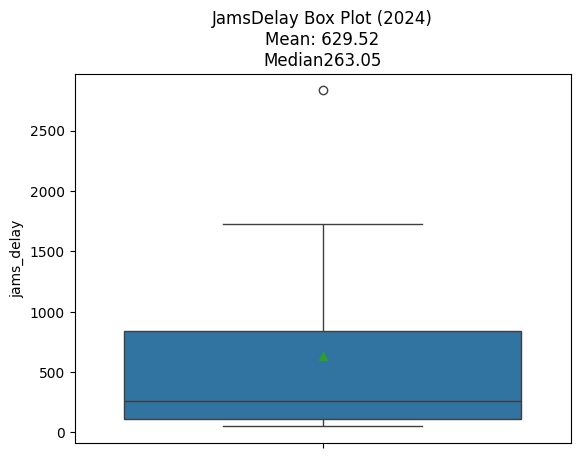

In [25]:
# Creating a box plot to observe the behavior of congestion delay (jams_delay)
sns.boxplot(data=merged, y='jams_delay',showmeans=True)
# Get mean to display in the title
mean_value = merged['jams_delay'].mean()
median_value = merged['jams_delay'].median()

plt.title(f'JamsDelay Box Plot (2024)\nMean: {mean_value:.2f}\nMedian{median_value:.2f}')
plt.show()

In [26]:




# The outlier corresponds with Mexico City, being the most congested city in the world
city_highestjam = merged.loc[merged['jams_delay'].idxmax(), 'city']
city_highestjam





'mexico-city'

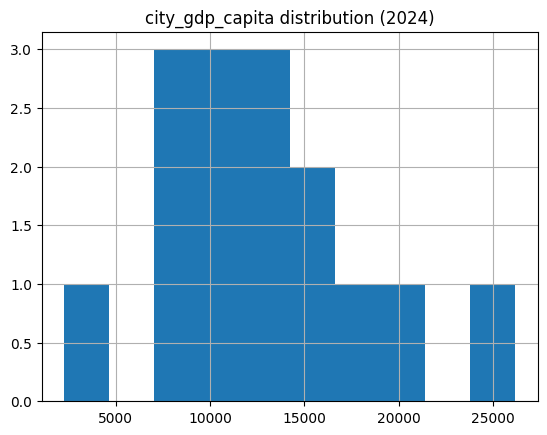

In [27]:
# Creating a histogram to see the city_gdp_capita distribution
merged['city_gdp_capita'].hist()
plt.title(f'city_gdp_capita distribution (2024)')
plt.show()



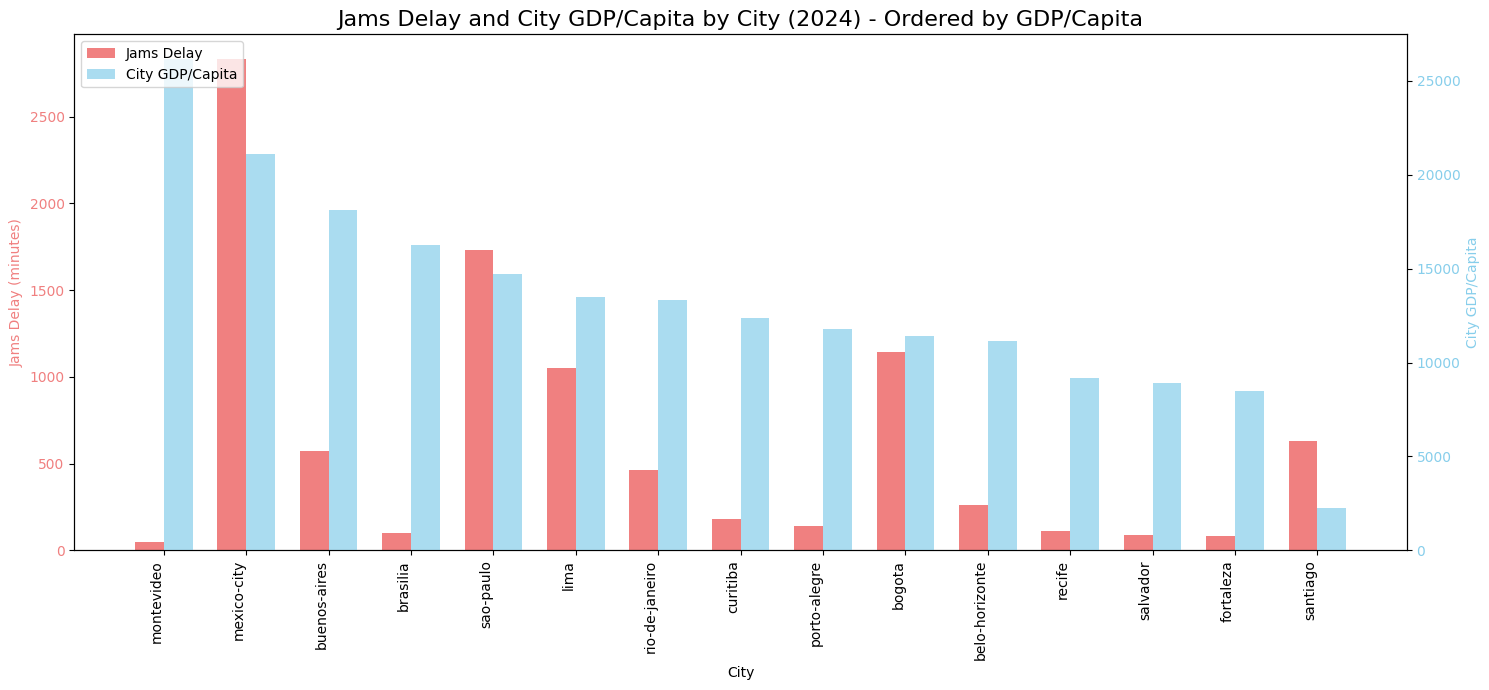

In [28]:
# Sort the DataFrame by 'city_gdp_capita'
merged_sorted_gdp = merged.sort_values(by='city_gdp_capita', ascending=False)

# Creating a figure and a primary axes (ax1) for 'jams_delay'
# The figsize parameter sets the width and height of the plot.
fig, ax1 = plt.subplots(figsize=(15, 7))

# Set the width of the bars
bar_width = 0.35

# Create an array of x-axis positions for the bars
# This will be used to position the bars for each city.
ind = np.arange(len(merged_sorted_gdp['city']))

# Plot 'jams_delay' on the primary y-axis (ax1)
# Position the bars slightly to the left of the city's index.
# 'lightcoral' is used for 'jams_delay'.
ax1.bar(ind - bar_width/2, merged_sorted_gdp['jams_delay'], width=bar_width, color='lightcoral', label='Jams Delay')
ax1.set_xlabel('City') # Set the label for the x-axis
ax1.set_ylabel('Jams Delay (minutes)', color='lightcoral') # Set the label and color for the primary y-axis
ax1.tick_params(axis='y', labelcolor='lightcoral') # Set the color for the primary y-axis tick labels

# Create a second y-axis (ax2) that shares the same x-axis as ax1
# This allows us to plot variables with different scales on the same chart.
ax2 = ax1.twinx()

# Plot 'city_gdp_capita' on the secondary y-axis (ax2)
# Position the bars slightly to the right of the city's index.
# 'skyblue' is used for 'city_gdp_capita' as requested.
ax2.bar(ind + bar_width/2, merged_sorted_gdp['city_gdp_capita'], width=bar_width, color='skyblue', alpha=0.7, label='City GDP/Capita')
ax2.set_ylabel('City GDP/Capita', color='skyblue') # Set the label and color for the secondary y-axis
ax2.tick_params(axis='y', labelcolor='skyblue') # Set the color for the secondary y-axis tick labels

# Set the title of the plot
plt.title('Jams Delay and City GDP/Capita by City (2024) - Ordered by GDP/Capita', fontsize=16)

# Set x-axis tick labels to be the city names and rotate for better readability
ax1.set_xticks(ind)
ax1.set_xticklabels(merged_sorted_gdp['city'], rotation=90, ha='right')

# Combine legends from both axes into a single legend for the chart
# This collects the handles (bars) and labels from both ax1 and ax2.
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# Adjust the layout to prevent labels and titles from overlapping
plt.tight_layout()

# Display the plot
plt.show()

## 🧩7: Correleations
To gain a clearer insight into the relationships between economic variables and mobility factors, it was utilized the correlation coefficient, denoted as .corr. This approach  allow us to analyze the connections across the variables that are of particular interest in our study.

Relying solely on bar charts may provide a visual representation of data, but it does not effectively capture the underlying relationships and trends between the variables (aside from the fact that it is difficult to visualize in one single graph). By employing correlation analysis, we can better understand the strength and direction of these relationships, enabling us to make more informed decisions and draw meaningful conclusions based on the data.

**🎯 Objective:**
Apply a correlation method to key variables of interest

**Steps**
1) Selecting the variables of interest: 'city_gdp_capita', 'jams_delay', 'unemployment_pct', 'population'
2) Applying .corr to merged in those variables of interest
3) Construct a heat map to better visualize the results and strenght of correlations

In [39]:
# Pearson
key_variables = ['city_gdp_capita', 'jams_delay', 'unemployment_pct', 'population']
corr_matrix = merged[key_variables].corr()
print(corr_matrix)

                  city_gdp_capita  jams_delay  unemployment_pct  population
city_gdp_capita          1.000000    0.282975         -0.514407    0.276688
jams_delay               0.282975    1.000000         -0.686956    0.878525
unemployment_pct        -0.514407   -0.686956          1.000000   -0.572405
population               0.276688    0.878525         -0.572405    1.000000


In [40]:
#Spearman
corr_matrix_spearman = merged[key_variables].corr(method = 'spearman')
print(corr_matrix_spearman)

                  city_gdp_capita  jams_delay  unemployment_pct  population
city_gdp_capita          1.000000    0.207143         -0.652368    0.303571
jams_delay               0.207143    1.000000         -0.487936    0.864286
unemployment_pct        -0.652368   -0.487936          1.000000   -0.411081
population               0.303571    0.864286         -0.411081    1.000000


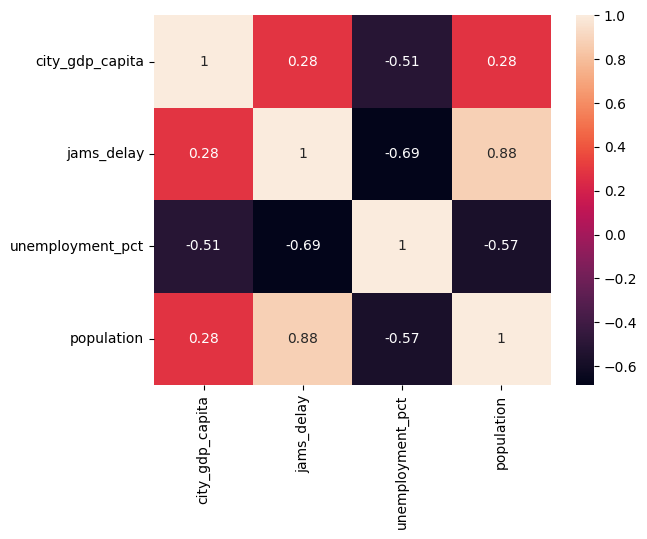

In [30]:



sns.heatmap(corr_matrix, annot = True)

# display the plot
plt.show()




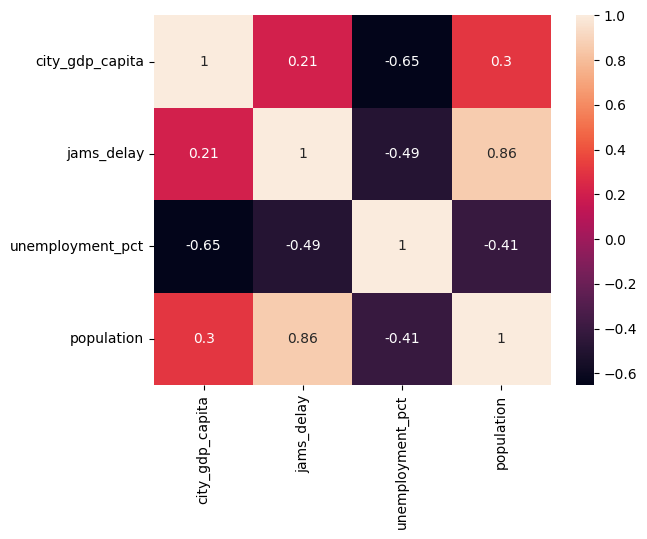

In [36]:
sns.heatmap(corr_matrix_spearman, annot = True)

# display the plot
plt.show()

## 🧩 8: Congestion Productivity Ratio

### 8.1.1 Calculation and Classification

**🎯 Objective:**
Calculate the congestion productivity ratio for each city and rank cities to identify those with the highest friction (high congestion relative to economic output).

In [31]:

# congestion_productivity_rati
merged['congestion_productivity_ratio'] = (
    merged['jams_delay'] / merged['city_gdp_capita']
)

# Sort descending to find the highest-friction / lowest-productivity cities
merged.sort_values(
    by='congestion_productivity_ratio', ascending=False
)[['city', 'jams_delay', 'city_gdp_capita', 'congestion_productivity_ratio']].reset_index()

,index,city,jams_delay,city_gdp_capita,congestion_productivity_ratio
0,13,santiago,629.865318,2277.0,0.276621
1,7,mexico-city,2833.057892,21111.0,0.134198
2,14,sao-paulo,1729.189270,14703.0,0.117608
3,1,bogota,1141.552364,11442.0,0.099769
4,6,lima,1052.292789,13472.0,0.078110
5,11,rio-de-janeiro,466.064706,13349.0,0.034914
6,3,buenos-aires,571.089593,18117.0,0.031522
7,0,belo-horizonte,263.047879,11124.0,0.023647
8,4,curitiba,183.469274,12381.0,0.014819
9,10,recife,112.755551,9189.0,0.012271


### 8.1.2 Visualizing the Congestion Productivity Ratio

**🎯 Objective:**
Visualize the congestion productivity ratio for each city to better understand the relationship between traffic delays and GDP per capita.

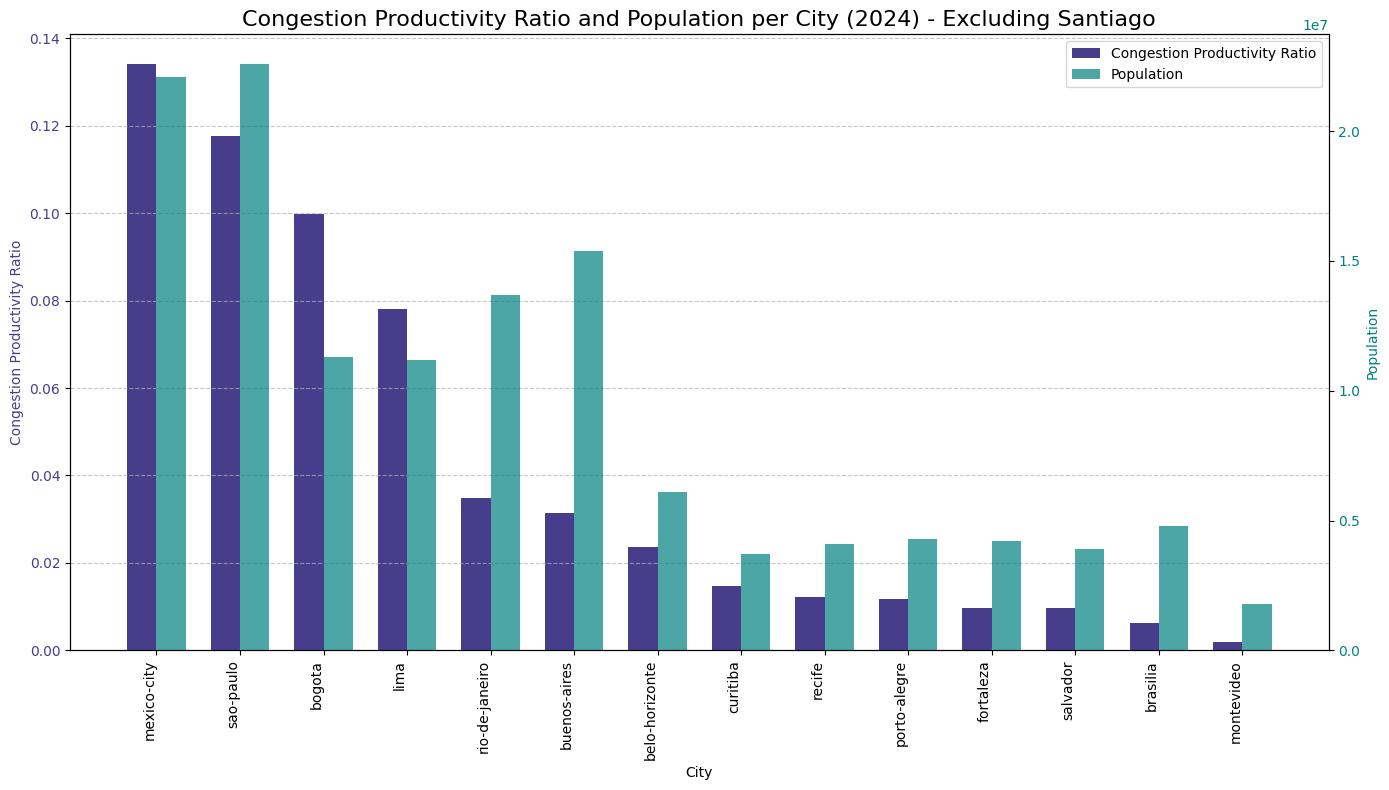

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sort the DataFrame by the ratio for better visualization
merged_sorted = merged.sort_values(by='congestion_productivity_ratio', ascending=False)

# Filter out 'Santiago' from the sorted DataFrame
merged_filtered = merged_sorted[merged_sorted['city'] != 'santiago']

# Create a figure and a primary axes (ax1) for 'congestion_productivity_ratio'
fig, ax1 = plt.subplots(figsize=(14, 8))

# Set the width of the bars
bar_width = 0.35

# Create an array of x-axis positions for the bars
ind = np.arange(len(merged_filtered['city']))

# Plot 'congestion_productivity_ratio' on the primary y-axis (ax1)
ax1.bar(ind - bar_width/2, merged_filtered['congestion_productivity_ratio'], width=bar_width, color='darkslateblue', label='Congestion Productivity Ratio')
ax1.set_xlabel('City') # Set the label for the x-axis
ax1.set_ylabel('Congestion Productivity Ratio', color='darkslateblue') # Set the label and color for the primary y-axis
ax1.tick_params(axis='y', labelcolor='darkslateblue') # Set the color for the primary y-axis tick labels

# Create a second y-axis (ax2) that shares the same x-axis as ax1
ax2 = ax1.twinx()

# Plot 'population' on the secondary y-axis (ax2)
ax2.bar(ind + bar_width/2, merged_filtered['population'], width=bar_width, color='teal', alpha=0.7, label='Population')
ax2.set_ylabel('Population', color='teal') # Set the label and color for the secondary y-axis
ax2.tick_params(axis='y', labelcolor='teal') # Set the color for the secondary y-axis tick labels

# Set the title of the plot
plt.title('Congestion Productivity Ratio and Population per City (2024) - Excluding Santiago', fontsize=16)

# Set x-axis tick labels to be the city names and rotate for better readability
ax1.set_xticks(ind)
ax1.set_xticklabels(merged_filtered['city'], rotation=90, ha='right')

# Combine legends from both axes into a single legend for the chart
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

# Add a grid for readability
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust the layout to prevent labels and titles from overlapping
plt.tight_layout()

# Display the plot
plt.show()


---

## 🧩9. Exportation and documentation of results

The work was consolidated, saved in a clean dataset and presented below in an executive summary documenting the results of the project.

### 9.1 Saving the dataset

**🎯Objetive:**
Generate a clean CSV, reproducible and with relevant columns for future analysis.

**Step by step**

- Export the DataFrame `merged` with the name: `ladb_mobility_economy_2024_clean.csv`
-  `index=False` is used to not include the index.


In [33]:
# Export the final dataset as CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 10. Executive summary


**Context & objective:**  
 Business question: What is the relationship between urban mobility (congestion, travel times) and economic productivity (GDP per capita)?

The analysis shows that the relationship between urban mobility (traffic delays) and economic productivity (GDP per capita) is weak and non-linear (Spearman r=0.21). Higher GDP per capita does not automatically result in greater traffic congestion. Instead, congestion is primarily driven by urban population size (r=0.86) and active labor force participation, as evidenced by a strong inverse correlation with unemployment (r=−0.69).

**Data coverage:**  
- The year analyzed was 2024, since it was the only one where both datasets had overlap.
- Seven Countries included (Brazil, Argentina, Colombia, Uruguay, Mexico, Peru and Chile)
- Fifteen cities analized, including: Bogotá, Buenos Aires, Brasília, Porto Alegre, Curitiba, Recife, Fortaleza, Salvador, Santiago, Rio de Janeiro, Belo Horizonte, Mexico City, São Paulo, Montevideo, Lima.

**Methodology:**  
1) Data cleaning & standardization:

- Standardized all column names across both datasets to snake_case format for consistency.
- Converted timestamp strings in the traffic dataset into datetime objects.
- Cleaned European numeric formatting in the economic dataset by stripping thousand separators (.), percentage signs (%), replacing decimal commas (,) with dots (.), and casting text fields to float or int.
- Created derived features, including an extracted year variable from timestamps and absolute population counts.
2) Aggregation & data integration (INNER JOIN):
- Aggregated high-frequency real-time traffic measurements into annual city-level averages (city, year) to align with the lower-frequency economic data.
- Filtered both datasets for 2024, the single year with full data overlap across both sources.
- Executed an INNER JOIN on ['city', 'year'] to merge mobility and economic metrics, ensuring the final dataset contained only complete, matched records across the target Latin American cities.
Visual validations & exploratory analysis:
- Evaluated variable distributions and scale disparities (e.g., identifying that plotting GDP and delay minutes on a single axis squashes traffic data).
- Analyzed general trends and potential outliers across cities using bar charts and scatter plot logic.
- Utilized a correlation and heatmap to systematically evaluate linear relationships between mobility indices (jams_delay), economic productivity (city_gdp_capita, unemployment_pct, population).
  
**Main findings:**  


1) Highest Strategic Urgency (Bogotá & Lima): Severe traffic friction paired with lower GDP per capita (Ratios: 0.100 and 0.078) yields the highest economic ROI per dollar spent on mass transit and smart traffic systems.

2) High-Scale Congestion (Mexico City & São Paulo): Record the highest absolute congestion (Ratios: 0.134 and 0.118), primarily driven by sheer population scale and dense urban activity.

3) Efficient Benchmarks (Montevideo & Brasília): Maintain high GDP per capita alongside minimal traffic delays, serving as models of balanced mobility and planning.

4) Key Statistical  drivers of mobilit:
Population ($r = 0.86$) is the primary driver of traffic delays (jams_delay). GDP per Capita ($r = 0.21$), on the other hand, has a weak correlation with congestion, showing economic output alone does not drive traffic.

5) Unemployment dynamics: Inversely correlates with GDP ($r = -0.51$), Congestion ($r = -0.69$, reflecting reduced commuter travel), and Population ($r = -0.57$).

-  **Potential errors, bias and outliers**
-  Worth noting: Santiago's 2024 GDP per capita entry (2,277 USD) causes it to rank artificially as a low-productivity city. This contradicts both historical data (such as its 2023 figure of 22,176 USD) and real-world economic indicators, as Santiago consistently ranks among the top LATAM cities in GDP per capita. This clearly points to an outlier or data collection error in the source dataset.

-  The dataset cointains nine cities from Brasil, and is the only country with more than one city in the dataset, which could lead to skewed results

- Notably, Mexico City stands out as a clear outlier with the highest jams_delay in the dataset. Unlike the anomaly in Santiago's GDP, this reflects real-world megacity traffic conditions rather than a data collection error.

**Recomendations**  

While Mexico City ($0.134$) and São Paulo ($0.118$) mathematically lead the congestion-to-productivity ratio ($\frac{\text{jams\_delay}}{\text{city\_gdp\_capita}}$) due to sheer megacity scale (larger populations), Bogotá ($0.100$) and Lima ($0.078$) show the highest strategic urgency. They suffer from severe traffic friction combined with lower economic output per capita, meaning targeted investments in urban transit (e.g., mass rapid transit, bus rapid transit expansion, and smart traffic control) will deliver the highest economic productivity return per dollar spent.
